In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [3]:
dataframe = pd.read_csv('results/benchmark_summaryTest.csv')
dataframe.head()

,solver,instance,instance_size,num_bins,num_runs,avg_ground_time,avg_solve_time,avg_total_time,cost,optimum,satisfiable,avg_choices,avg_conflicts,avg_restarts,atoms
0,clingcon,layered_medium_seed1,medium,0,5,0.013,60.006,60.019,66068,False,True,807889.0,621274.4,7277.6,2217
1,clingcon,layered_medium_seed1,medium,1,5,0.008,60.055,60.063,415284,False,True,1022322.6,848687.4,8767.8,4036
2,clingcon,layered_medium_seed1,medium,2,5,0.011,60.143,60.155,411528,False,True,2379814.8,1518765.4,15627.0,5855
3,clingcon,layered_medium_seed1,medium,3,5,0.014,60.050,60.064,420888,False,True,1824839.8,824076.4,7941.4,7674
4,clingcon,layered_medium_seed1,medium,4,5,0.026,60.029,60.054,373176,False,True,1836117.0,1348485.6,8349.8,9493


## Total solving time taken

One thing to note: 

Optimised adds 4 major pruning techniques (lines 93-101 of      
  optimised):                                               
                                                                  
  1. Symmetry breaking — bins forced to be used in order +        
  higher-ID bins get ≤ frequency of lower bins                    
  2. Tighter variable domains — auxilary uses                     
  per-part/per-transport bound (C/S * maxFreq) instead of global  
  maxItems * maxFreq                                              
  3. Flow restriction — canFlow predicate eliminates impossible
  flow variables (no flow FROM customers, no flow TO suppliers)   
  4. Frequency-pack consistency — empty bins forced to zero
  frequency, loaded bins must dispatch ≥ 1


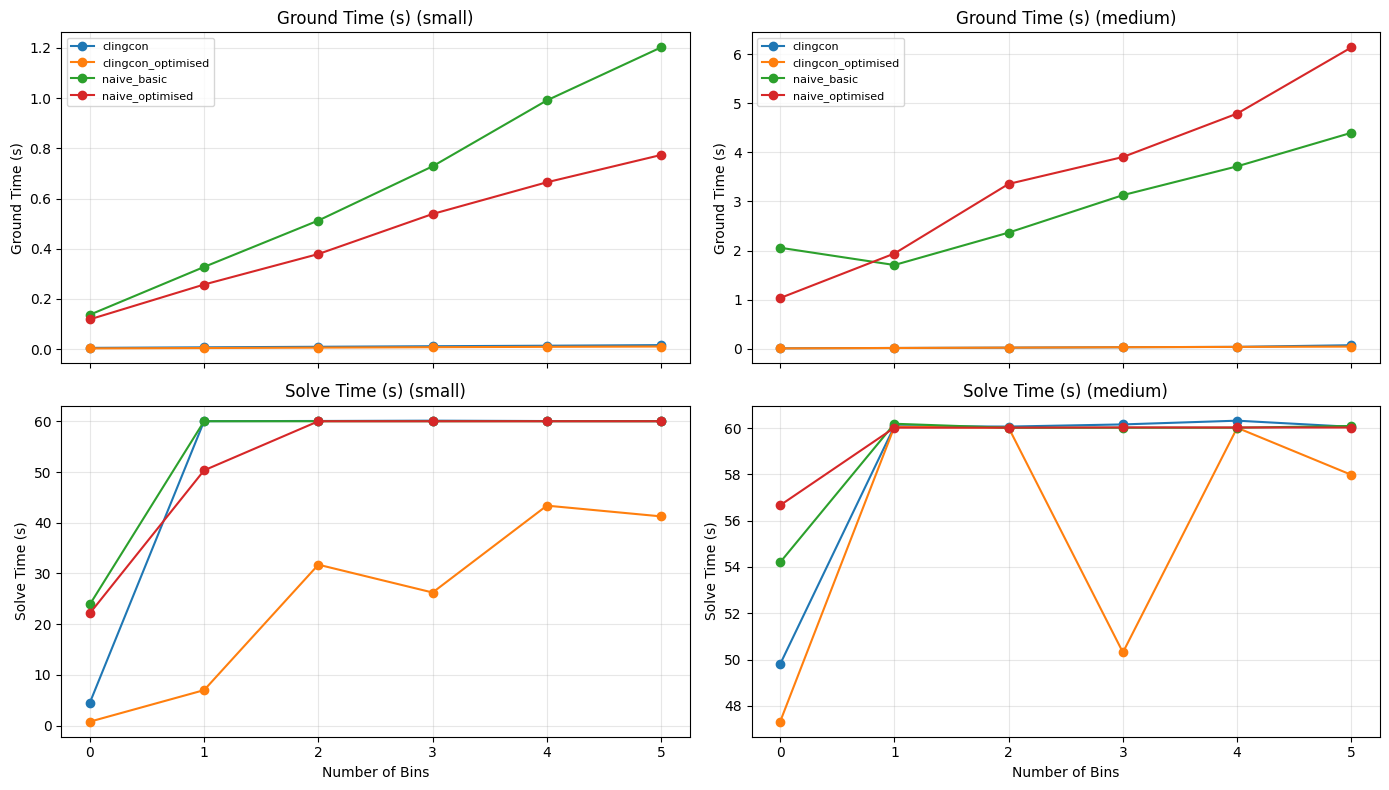

In [4]:
sizes = ['small', 'medium']
time_metrics = ['avg_ground_time', 'avg_solve_time']

fig, axes = plt.subplots(len(time_metrics), len(sizes), figsize=(14, 8), sharex=True)

for col, size in enumerate(sizes):
    size_df = dataframe[dataframe['instance_size'] == size]
    avg_df = size_df.groupby(['solver', 'num_bins'])[time_metrics].mean().reset_index()

    for row, metric in enumerate(time_metrics):
        ax = axes[row, col]
        for solver, group in avg_df.groupby('solver'):
            ax.plot(group['num_bins'], group[metric], marker='o', label=solver)
        label = 'Ground Time (s)' if 'ground' in metric else 'Solve Time (s)'
        ax.set_ylabel(label)
        ax.set_title(f'{label} ({size})')
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.legend(fontsize=8)
        if row == len(time_metrics) - 1:
            ax.set_xlabel('Number of Bins')

plt.tight_layout()
plt.show()

  Choices — Number of decision points solver made. Each choice =  
  solver picking a truth value for an atom when it can't be       
  determined by propagation. More choices = larger search space   
  explored. High count means problem harder for solver to         
  navigate.                                                       
                                                            
  Conflicts — Times solver hit contradiction after making choices.
  Conflict = current partial assignment can't lead to solution,
  triggers backtracking. High conflicts relative to choices =
  solver exploring many dead ends. Low ratio = solver making good
  decisions.

  Restarts — Times solver abandoned current search path and
  started fresh with learned conflict clauses. Restarts help
  escape bad decision orderings. More restarts = solver struggling
   with initial variable ordering, using learned knowledge to try
  better paths.

  What we notice here is that the clingcon and the clingo encoding have the same level of choices however, its in the propergation theory where there are bottle necks.   Naive clingo (pure ASP):                       
  - Everything ground to propositional atoms (look at atoms column
   — hundreds of thousands to millions)                     
  - Boolean Constraint Propagation (BCP) works directly on all
  these atoms                                    
  - When solver makes a choice, implications ripple through
  massive clause network immediately
  - Conflicts detected early before going deep — so fewer
  conflicts per choice
  - Fewer deep dead-ends = fewer restarts needed
  - Cost: grounding is enormous and slow

  Clingcon (theory constraints):
  - Tiny grounding (few thousand atoms)
  - Integer variables handled by separate theory solver, not
  propositional clauses
  - ASP solver makes choice → propagates propositionally → then
  asks theory solver "is this still consistent?"
  - Theory solver discovers violations later than BCP would —
  conflict detected deeper in search tree
  - Deeper conflicts = more backtracking = more conflicts and
  restarts
  - This is called lazy theory propagation — theory solver only
  checks when asked, doesn't propagate as aggressively as BCP

  TL;DR: Naive encoding gives solver more propositional
  information to reason with (strong propagation, early conflict
  detection), but pays for it with massive grounding. Clingcon
  keeps grounding small but the theory solver communicates less
  efficiently with the ASP solver, so conflicts happen deeper and
  more often.

  Similar choices because both explore comparable search spaces —
  but naive catches bad paths sooner (fewer conflicts/restarts)
  while clingcon discovers them late.

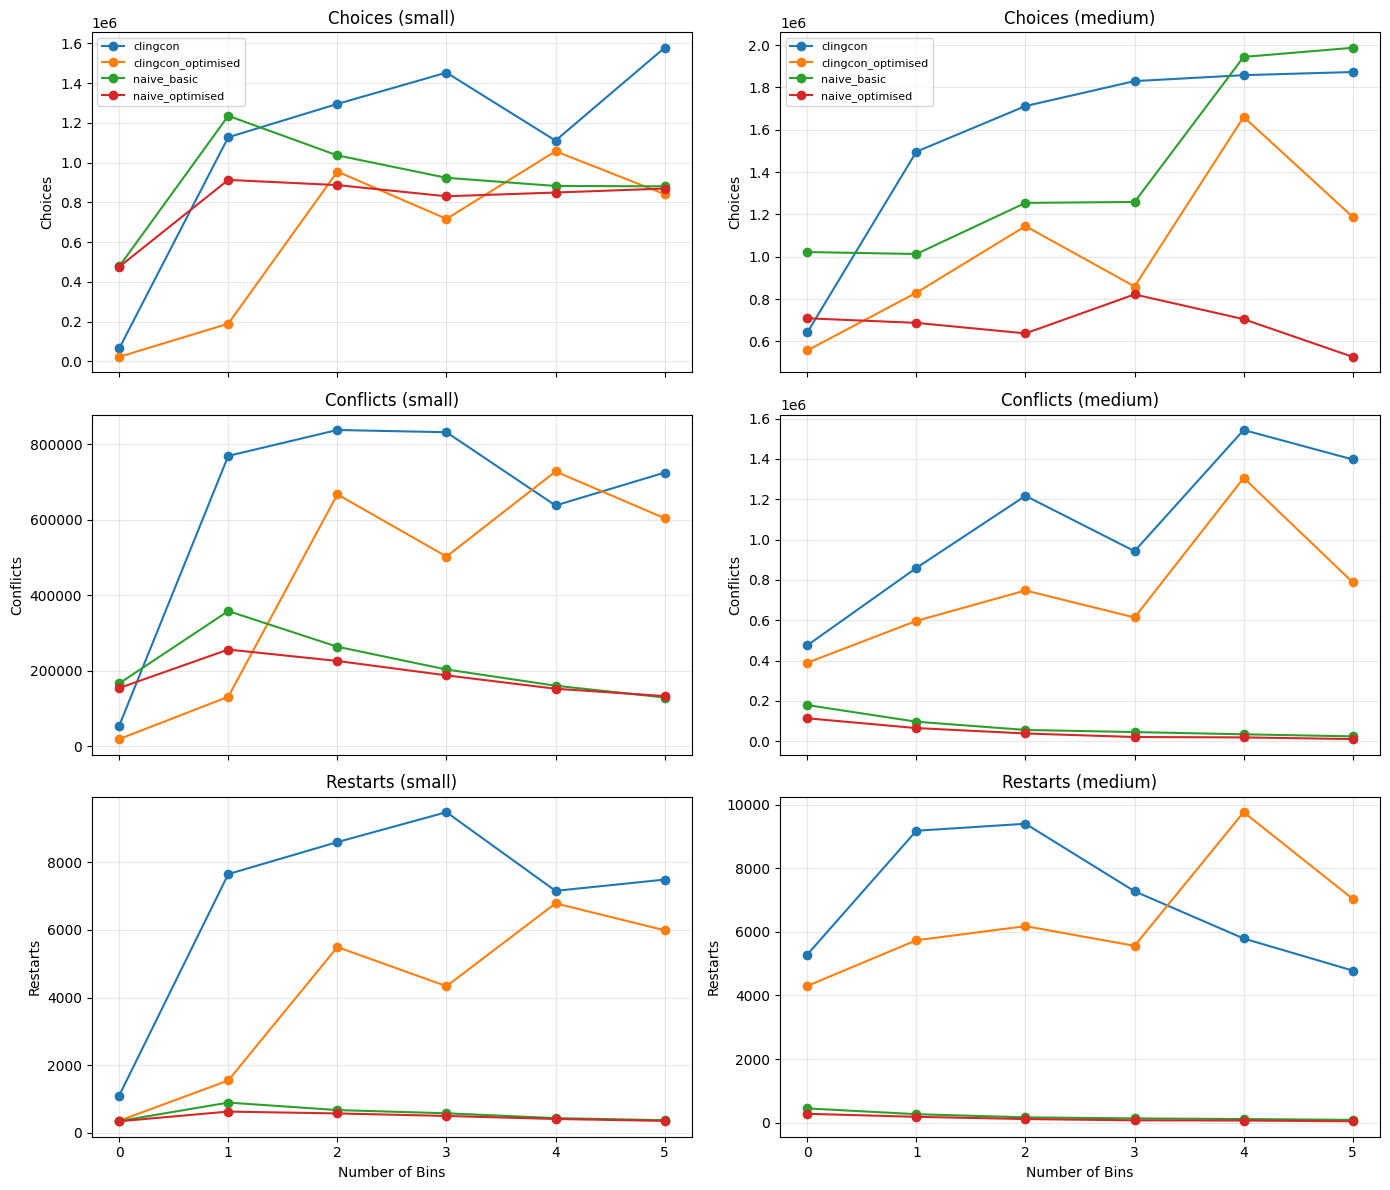

In [5]:
metrics = ['avg_choices', 'avg_conflicts', 'avg_restarts']
sizes = ['small', 'medium']

fig, axes = plt.subplots(len(metrics), len(sizes), figsize=(14, 12), sharex=True)

for col, size in enumerate(sizes):
    size_df = dataframe[dataframe['instance_size'] == size]
    avg_df = size_df.groupby(['solver', 'num_bins'])[metrics].mean().reset_index()

    for row, metric in enumerate(metrics):
        ax = axes[row, col]
        for solver, group in avg_df.groupby('solver'):
            ax.plot(group['num_bins'], group[metric], marker='o', label=solver)
        ax.set_ylabel(metric.replace('avg_', '').replace('_', ' ').title())
        ax.set_title(f'{metric.replace("avg_", "").replace("_", " ").title()} ({size})')
        ax.grid(True, alpha=0.3)
        if row == 0:
            ax.legend(fontsize=8)
        if row == len(metrics) - 1:
            ax.set_xlabel('Number of Bins')

plt.tight_layout()
plt.show()

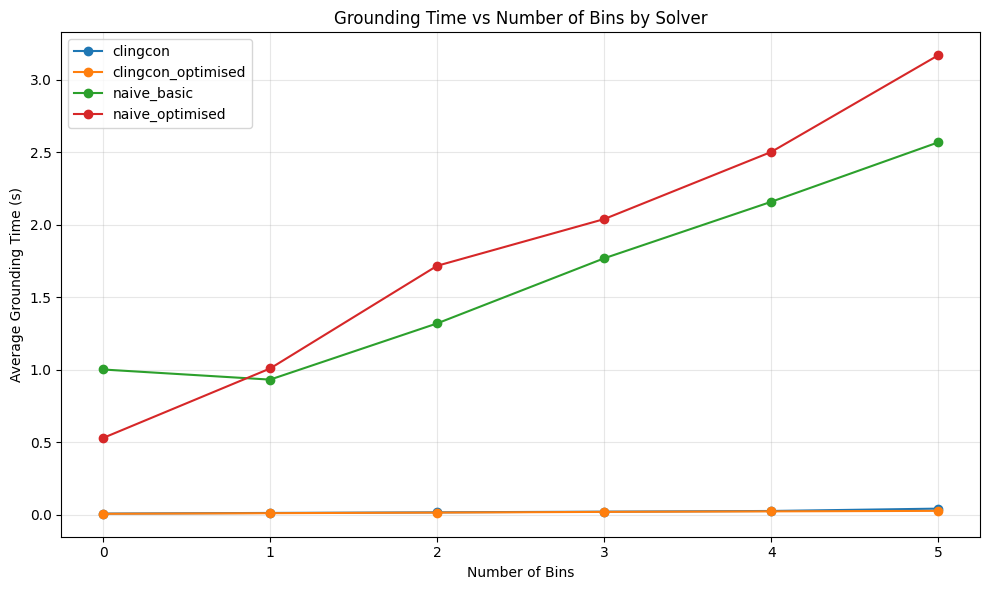

In [6]:
# average grounding time taken 

avg_by_solver = dataframe.groupby(['solver', 'num_bins'])['avg_ground_time'].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for solver, group in avg_by_solver.groupby('solver'):
    ax.plot(group['num_bins'], group['avg_ground_time'], marker='o', label=solver)

ax.set_xlabel('Number of Bins')
ax.set_ylabel('Average Grounding Time (s)')
ax.set_title('Grounding Time vs Number of Bins by Solver')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Per-Seed Solve Time Breakdown

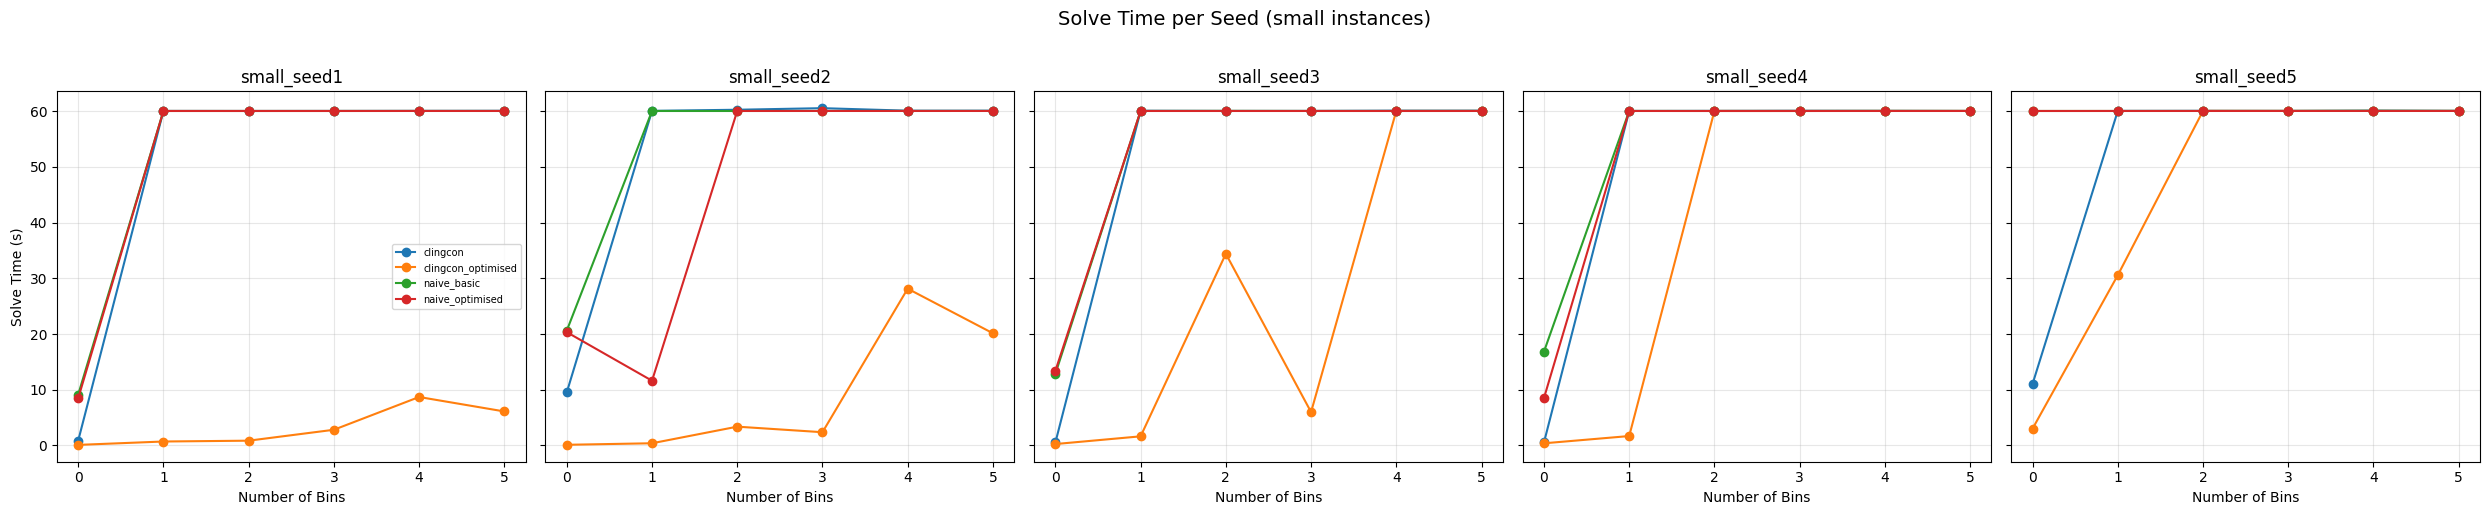

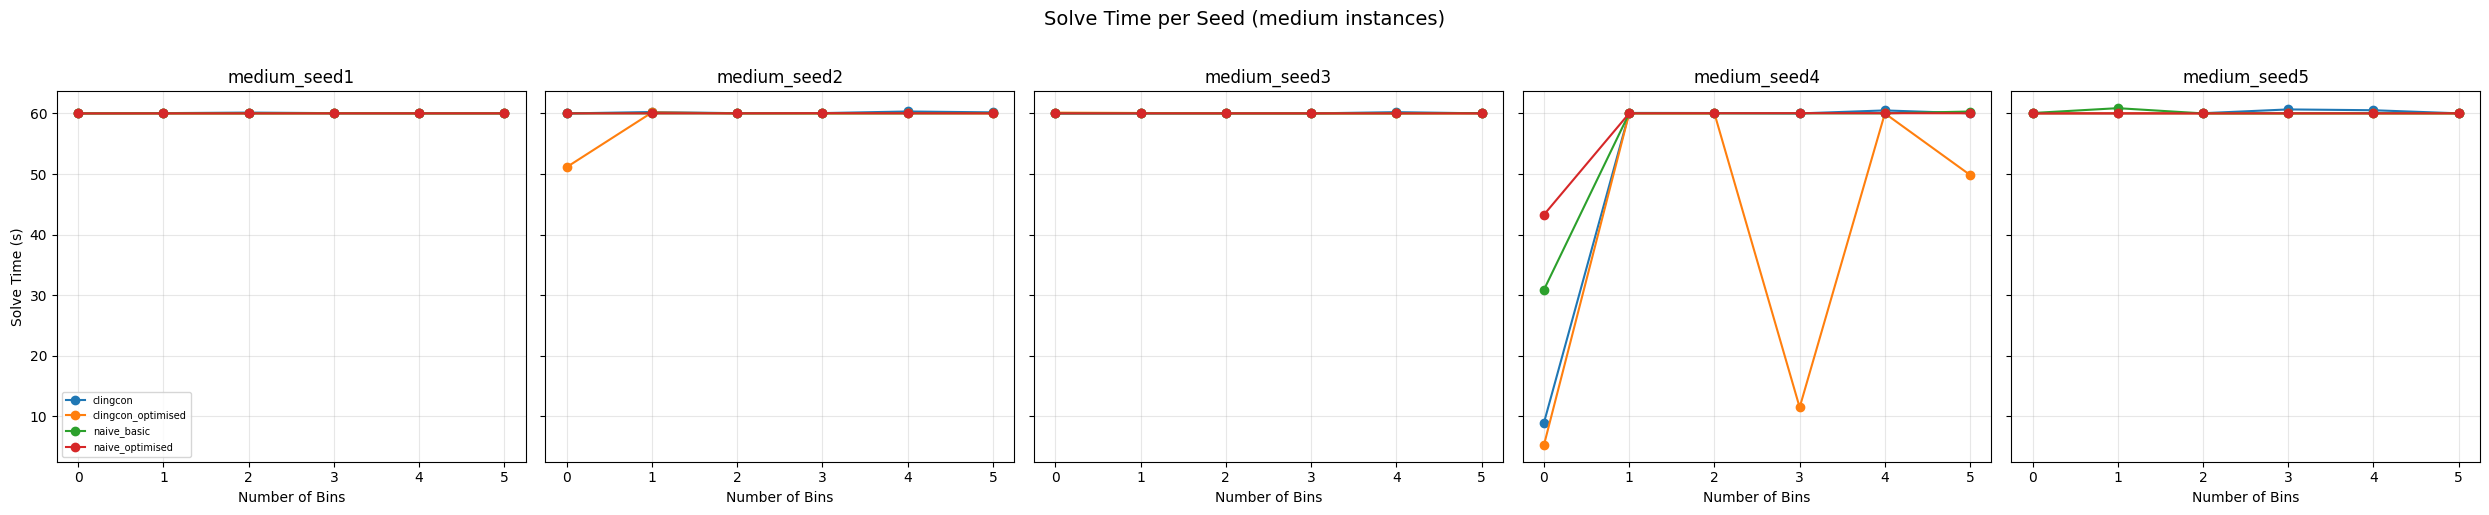

In [8]:
sizes = ['small', 'medium']                           
solvers = dataframe['solver'].unique()
                                                        
for size in sizes:                                    
      size_df = dataframe[dataframe['instance_size'] ==size]           
      seeds = sorted(size_df['instance'].unique())                               
      fig, axes = plt.subplots(1, len(seeds), figsize=(5* len(seeds), 5), sharey=True)
      fig.suptitle(f'Solve Time per Seed ({size} instances)', fontsize=14, y=1.02)
      for i, seed in enumerate(seeds):
          ax = axes[i]
          seed_df = size_df[size_df['instance'] == seed]
          for solver, group in seed_df.groupby('solver'):
              ax.plot(group['num_bins'], group['avg_solve_time'], marker='o', label=solver)
          ax.set_xlabel('Number of Bins')
          ax.set_title(seed.replace('layered_', ''))
          ax.grid(True, alpha=0.3)
          if i == 0:
              ax.set_ylabel('Solve Time (s)')
              ax.legend(fontsize=7)

      plt.tight_layout()
      plt.show()

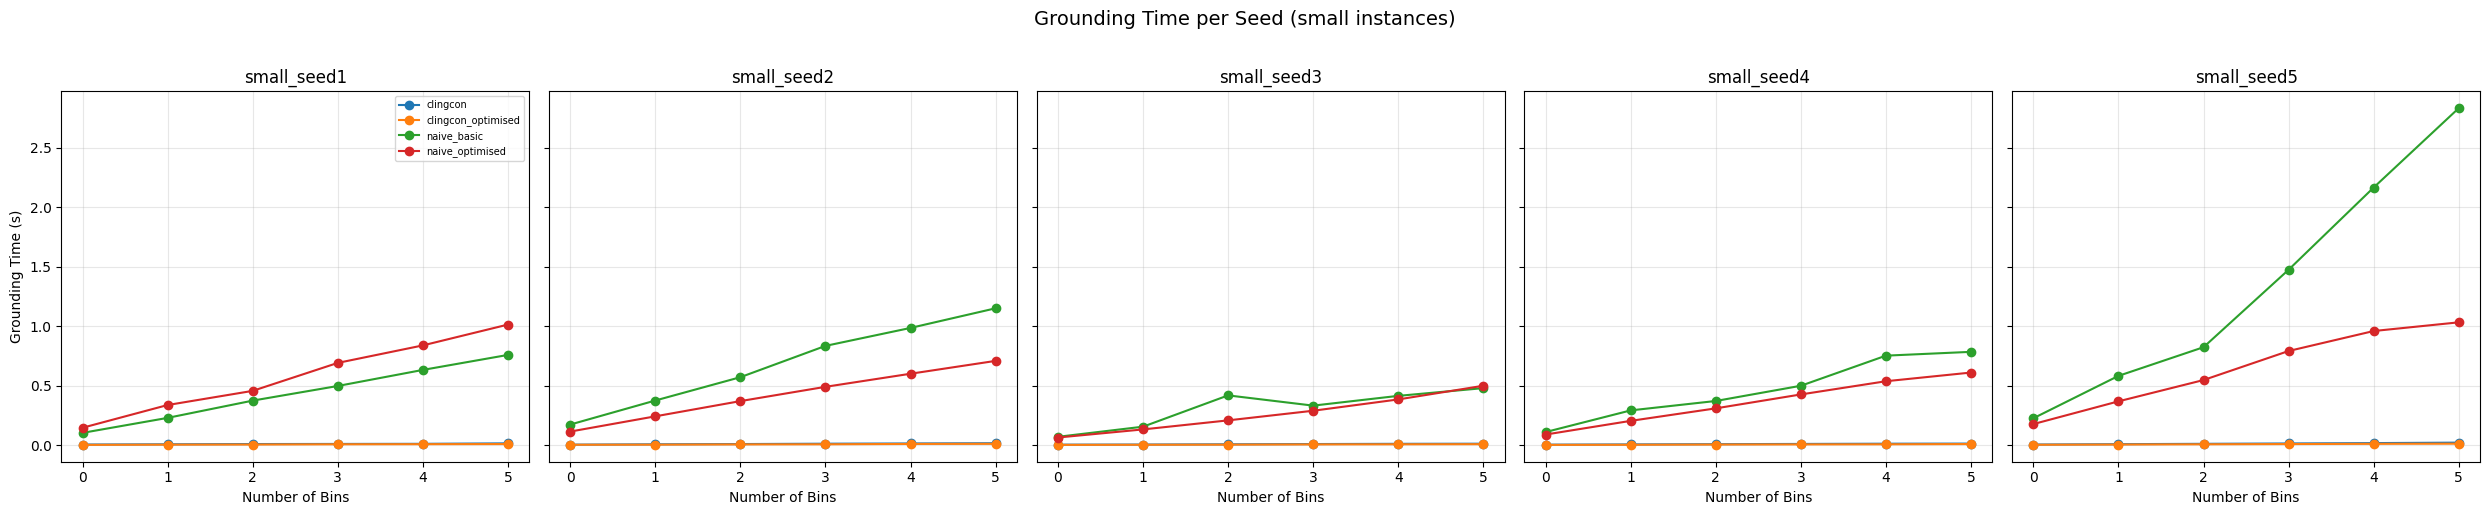

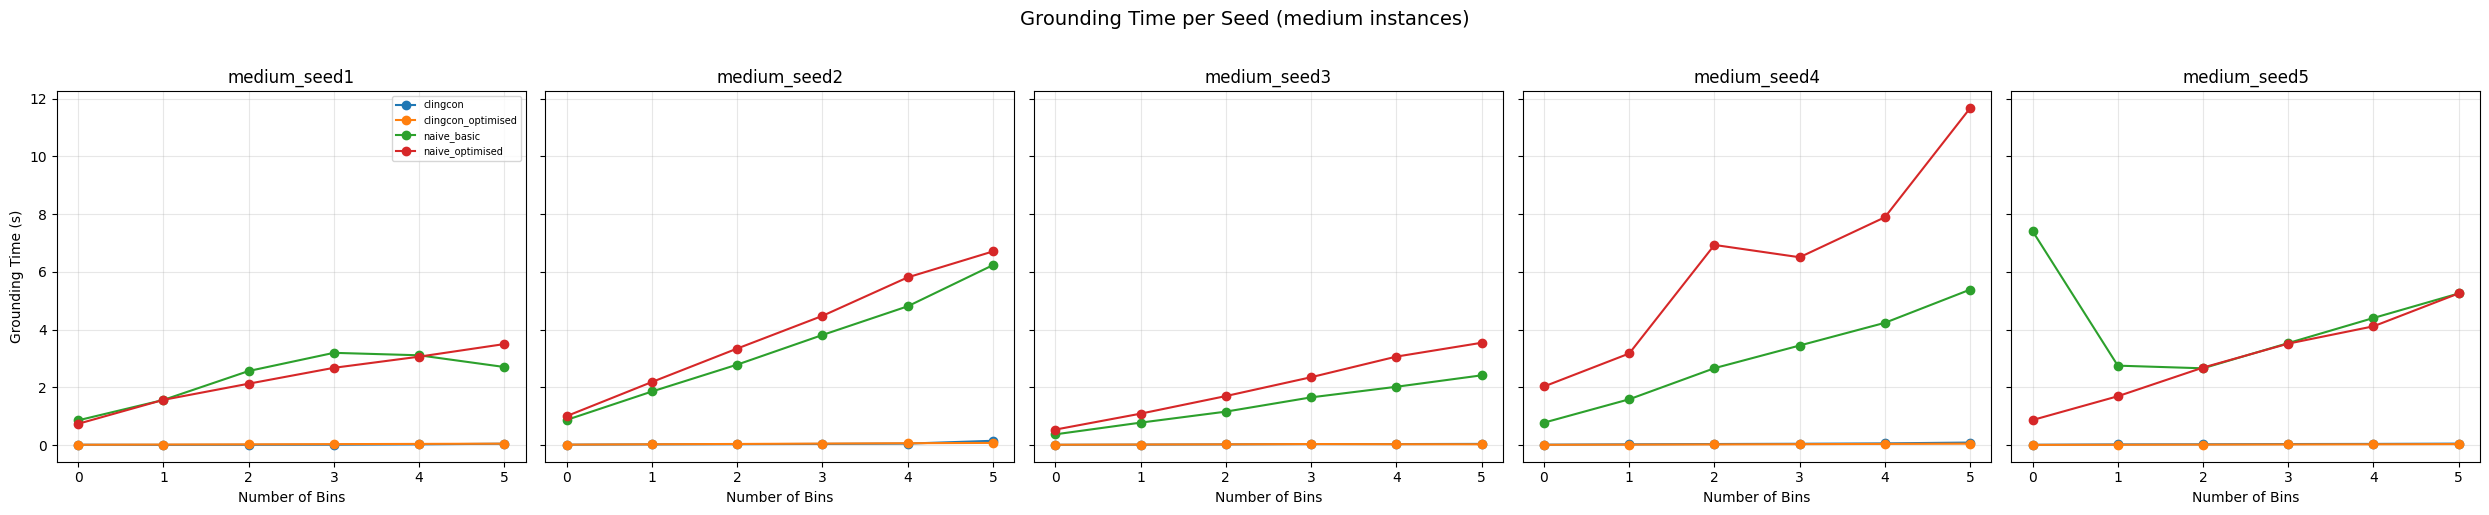

In [9]:
sizes = ['small', 'medium']                           
solvers = dataframe['solver'].unique()
                                                        
for size in sizes:                                    
      size_df = dataframe[dataframe['instance_size'] ==size]           
      seeds = sorted(size_df['instance'].unique())                               
      fig, axes = plt.subplots(1, len(seeds), figsize=(5* len(seeds), 5), sharey=True)
      fig.suptitle(f'Grounding Time per Seed ({size} instances)', fontsize=14, y=1.02)
      for i, seed in enumerate(seeds):
          ax = axes[i]
          seed_df = size_df[size_df['instance'] == seed]
          for solver, group in seed_df.groupby('solver'):
              ax.plot(group['num_bins'], group['avg_ground_time'], marker='o', label=solver)
          ax.set_xlabel('Number of Bins')
          ax.set_title(seed.replace('layered_', ''))
          ax.grid(True, alpha=0.3)
          if i == 0:
              ax.set_ylabel('Grounding Time (s)')
              ax.legend(fontsize=7)

      plt.tight_layout()
      plt.show()